In [1]:
from sldl import SignLanguageDataset
from sldl.targets.temporal_segmentation import TemporalSegmentationTarget

import matplotlib.pyplot as plt

In [2]:
root = "F:/datasets/sign-language/lsfb-cont"
shards_url = f"file:{root}/shards/annotated/" + "shard_{000000..000005}.tar"

In [3]:
dataset = SignLanguageDataset(
    shards_url=shards_url,
    use_windows=True,
    window_size=3500,
    window_stride=2800,
    max_empty_windows=0,
    targets={
        'temporal-segmentation': TemporalSegmentationTarget(),
    },
    precompute_targets=True,
    load_videos=True,
    video_path=f"{root}/videos.tar",
    video_index_path=f"{root}/videos.tar.index.json",
    show_loading_progress=True,
)

len(dataset)

Loading dataset [file:F:/datasets/sign-language/lsfb-cont/shards/annotated/shard_{000000..000005}.tar]...


Loading samples: 378 samples [00:07, 52.05 samples/s]


Loaded 378 samples.
Building windows of size 3500 with stride 2800...
Converted 378 samples to 2663 windowed samples.
Removed 264 empty samples. There are 2399 final samples.
Precomputing targets...
Target precomputed.


2399

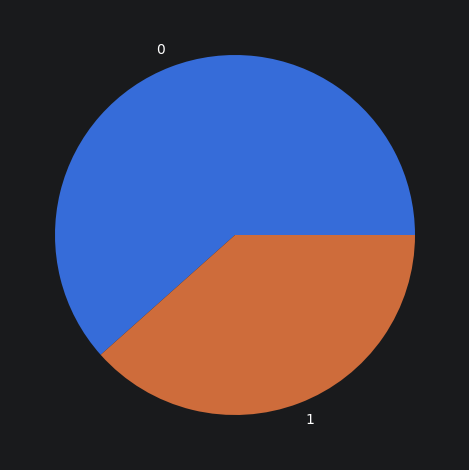

{0: 0.6159120681080252, 1: 0.38408793189197477}

In [4]:
frequencies = dataset.get_label_frequencies('temporal-segmentation')

labels, label_frequencies = zip(*frequencies.items())

plt.figure()
plt.pie(label_frequencies, labels=labels)
plt.tight_layout()
plt.show()

frequencies

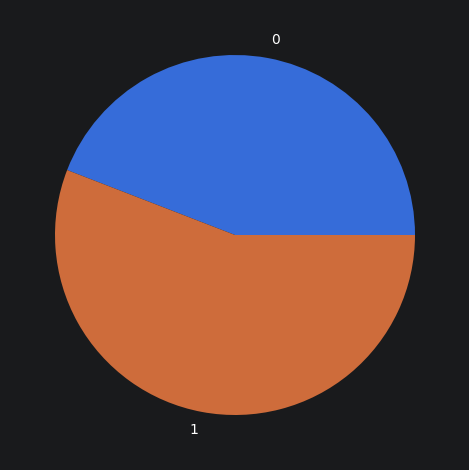

{0: np.float64(0.8824872742416802), 1: np.float64(1.11751272575832)}

In [5]:
weights = dataset.get_label_weights('temporal-segmentation', strategy='inverse_sqrt')

labels, label_weights = zip(*weights.items())

plt.figure()
plt.pie(label_weights, labels=labels)
plt.tight_layout()
plt.show()

weights